In [23]:
from kan import *
torch.set_default_dtype(torch.float64)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

# create a KAN: 2D inputs, 1D output, and 5 hidden neurons. cubic spline (k=3), 5 grid intervals (grid=5).
kan_model = KAN(width=[2,5,1], grid=3, k=3, seed=42, device=device)
mpkan_model = MPKAN(width=[2,5,1], grid=3, k=3, seed=42, device=device)
compiled_kan_model = KAN(width=[2,5,1], grid=3, k=3, seed=42, device=device).speed(compile=True)
compiled_mpkan_model = MPKAN(width=[2,5,1], grid=3, k=3, seed=42, device=device).speed(compile=True)

cuda
checkpoint directory created: ./model
saving model version 0.0
checkpoint directory created: ./model
saving model version 0.0
checkpoint directory created: ./model
saving model version 0.0
checkpoint directory created: ./model
saving model version 0.0


Create dataset

In [24]:
from kan.utils import create_dataset
from torch.distributions.normal import Normal

eps = 1e-6

# create dataset f(x,y) = exp(sin(pi*x)+y^2)
f = lambda x: (
    x[:, [0]].clamp(min=eps) * Normal(0, 1).cdf(
        (torch.log((x[:, [0]] / x[:, [1]].clamp(min=eps)).clamp(min=eps)) +
         (x[:, [3]] + 0.5 * x[:, [4]]**2) * x[:, [2]]) /
        (x[:, [4]].clamp(min=eps) * torch.sqrt(x[:, [2]].clamp(min=eps)) + eps)
    ) -
    x[:, [1]].clamp(min=eps) * torch.exp(-x[:, [3]] * x[:, [2]]) *
    Normal(0, 1).cdf(
        (torch.log((x[:, [0]] / x[:, [1]].clamp(min=eps)).clamp(min=eps)) +
         (x[:, [3]] - 0.5 * x[:, [4]]**2) * x[:, [2]]) /
        (x[:, [4]].clamp(min=eps) * torch.sqrt(x[:, [2]].clamp(min=eps)) + eps)
    )
)
dataset = create_dataset(f, n_var=5, train_num=100, test_num=100, device=device)
dataset['train_input'].shape, dataset['train_label'].shape

(torch.Size([100, 5]), torch.Size([100, 1]))

Plot KAN at initialization

In [25]:
# plot KAN at initialization
kan_model(dataset['train_input']);
# kan_model.plot()

# plot MPKAN at initialization
mpkan_model(dataset['train_input']);
# mpkan_model.plot()

Train KAN with sparsity regularization

In [26]:
# train the kan_model
kan_metrics = kan_model.fit(dataset, opt="Adam", steps=50, lamb=0.001, profile=True)

| train_loss: 7.14e-01 | test_loss: 2.48e+00 | reg: 4.44e+01 | : 100%|█| 50/50 [00:01<00:00, 32.89it


-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg       CPU Mem  Self CPU Mem      CUDA Mem  Self CUDA Mem    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                          ProfilerStep*         0.00%       0.000us         0.00%       0.000us       0.000us      68.043ms       441.61%      68.043ms      22.681ms           0 b           0 b           0 b           0 

In [27]:
mpkan_metrics = mpkan_model.fit(dataset, opt="Adam", steps=50, lamb=0.001, profile=True)

| train_loss: 7.14e-01 | test_loss: 2.48e+00 | reg: 4.44e+01 | : 100%|█| 50/50 [00:01<00:00, 25.30it


-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg       CPU Mem  Self CPU Mem      CUDA Mem  Self CUDA Mem    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                          ProfilerStep*         0.00%       0.000us         0.00%       0.000us       0.000us     133.803ms       860.78%     133.803ms      44.601ms           0 b           0 b           0 b           0 

In [28]:
compiled_kan_metrics = compiled_kan_model.fit(dataset, opt="Adam", steps=50, lamb=0.001, profile=True)

setting lamb=0. If you want to set lamb > 0, set self.save_act=True


| train_loss: 5.05e-01 | test_loss: 4.82e-01 | reg: 0.00e+00 | : 100%|█| 50/50 [00:01<00:00, 31.12it


-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg       CPU Mem  Self CPU Mem      CUDA Mem  Self CUDA Mem    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                          ProfilerStep*         0.00%       0.000us         0.00%       0.000us       0.000us      48.985ms       692.74%      48.985ms      16.328ms           0 b           0 b           0 b           0 

In [29]:
compiled_mpkan_metrics = compiled_mpkan_model.fit(dataset, opt="Adam", steps=50, lamb=0.001, profile=True)

setting lamb=0. If you want to set lamb > 0, set self.save_act=True


| train_loss: 5.05e-01 | test_loss: 4.82e-01 | reg: 0.00e+00 | : 100%|█| 50/50 [00:01<00:00, 44.20it


-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg       CPU Mem  Self CPU Mem      CUDA Mem  Self CUDA Mem    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                          ProfilerStep*         0.00%       0.000us         0.00%       0.000us       0.000us      68.578ms       952.25%      68.578ms      22.859ms           0 b           0 b           0 b           0 

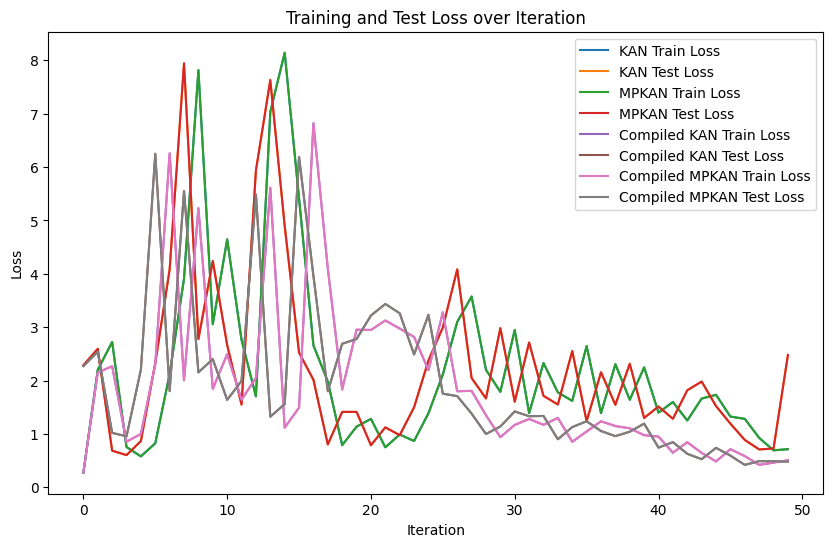

In [31]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 6))

plt.plot(np.array(kan_metrics['train_loss']), label='KAN Train Loss')
plt.plot(np.array(kan_metrics['test_loss']), label='KAN Test Loss')
plt.plot(np.array(mpkan_metrics['train_loss']), label='MPKAN Train Loss')
plt.plot(np.array(mpkan_metrics['test_loss']), label='MPKAN Test Loss')
plt.plot(np.array(compiled_kan_metrics['train_loss']), label='Compiled KAN Train Loss')
plt.plot(np.array(compiled_kan_metrics['test_loss']), label='Compiled KAN Test Loss')
plt.plot(np.array(compiled_mpkan_metrics['train_loss']), label='Compiled MPKAN Train Loss')
plt.plot(np.array(compiled_mpkan_metrics['test_loss']), label='Compiled MPKAN Test Loss')

plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Training and Test Loss over Iteration')
plt.legend()  # No arguments needed; uses the labels above
plt.show()
